# Part 1 - Exploring the Spectra, Testing Bohr and Orbital Model

Learning Goals
C7.1 Explain the connection between magnetism and angular momentum

So far you've worked with electronic Hamiltonians only. What if you wanted to know how your system behaved in the presence of a magnetic field?

Well, you could use a magnetic Hamiltonian.

$$
H = H_0 + V_m
$$
Where 
$$
V_m = \bold{-\mu} \cdot{} \bold{B} 
$$

In this section we'll explore what it looks like to add this magnetic term to various models of the hydrogen atom, and compare the resulting energy levels with real hydrogen spectra.

## 1.A - The Spectra

We've provided some H atom spectra, in an increasingly strong magnetic field. 

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

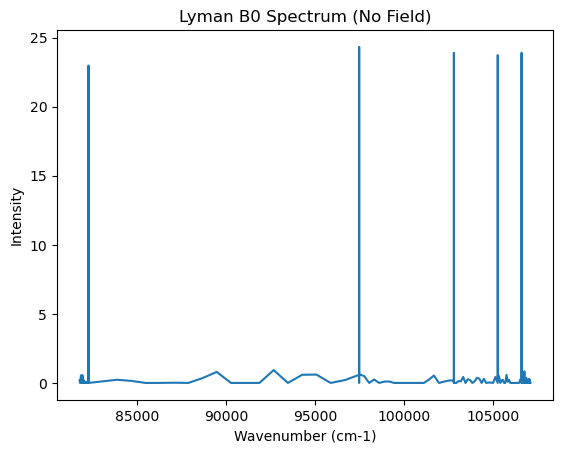

In [2]:
## NO FIELD
## columns: wavenumber_cm-1,intensity
b0 = pd.read_csv('data/lyman_B0.csv')
x = b0['wavenumber_cm-1']
y = b0['intensity']
plt.plot(x, y)
plt.xlabel('Wavenumber (cm-1)')
plt.ylabel('Intensity')
plt.title('Lyman B0 Spectrum (No Field)')
plt.show()

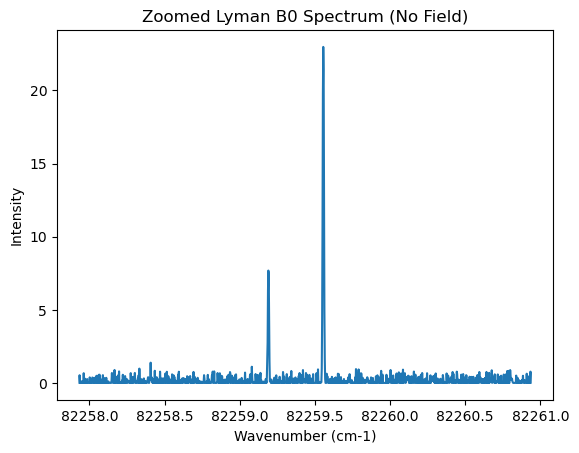

In [3]:
## Now zoom in on the first peak to see the fine structure
# twiddle with the numbers to get the right range
peak1 = b0[(b0['wavenumber_cm-1'] > 82250) &(b0['wavenumber_cm-1'] < 82400)]
# record these numbers for later
xmin = 82250
xmax = 82400


x = peak1['wavenumber_cm-1']
y = peak1['intensity']
plt.plot(x, y)
plt.xlabel('Wavenumber (cm-1)')
plt.ylabel('Intensity')
plt.title('Zoomed Lyman B0 Spectrum (No Field)')
plt.show()

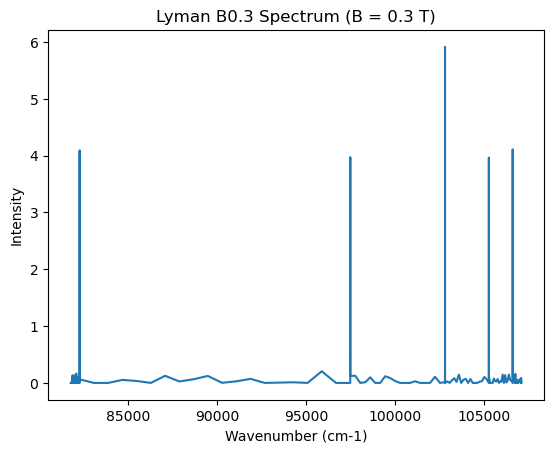

In [4]:
### YOUR TURN - REPEAT FOR THE OTHER TWO SPECTRA
# lyman_B03.csv
data = pd.read_csv('data/lyman_B03.csv')
x = data['wavenumber_cm-1']
y = data['intensity']
plt.plot(x, y)
plt.xlabel('Wavenumber (cm-1)')
plt.ylabel('Intensity')
plt.title('Lyman B0.3 Spectrum (B = 0.3 T)')
plt.show()

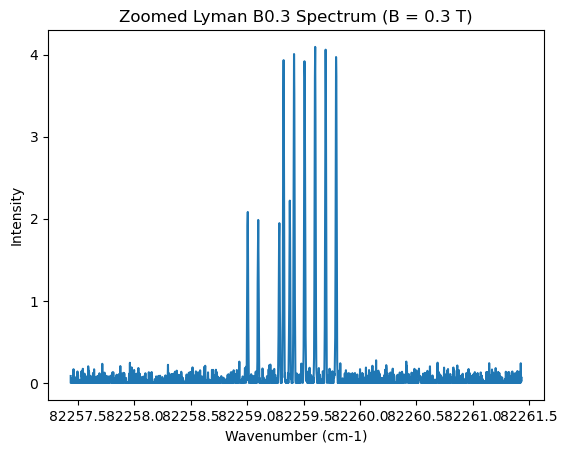

In [5]:
peak_region = data[(data['wavenumber_cm-1'] > xmin) &(data['wavenumber_cm-1'] < xmax)]
x = peak_region['wavenumber_cm-1']
y = peak_region['intensity']
plt.plot(x, y)
plt.xlabel('Wavenumber (cm-1)')
plt.ylabel('Intensity')
plt.title('Zoomed Lyman B0.3 Spectrum (B = 0.3 T)')
plt.show()

81753.765836
107138.097546


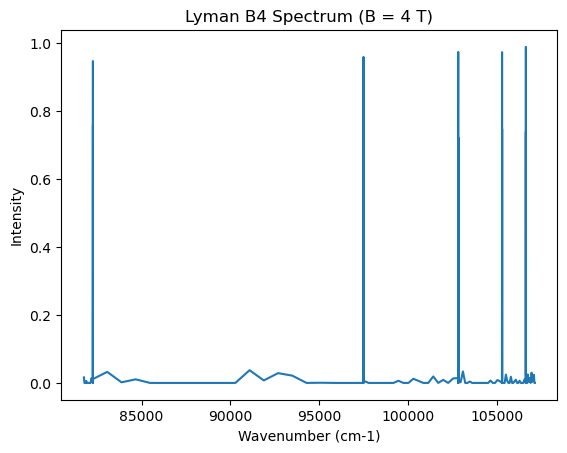

In [6]:
## lyman_B4.csv
data = pd.read_csv('data/lyman_B4.csv')
x = data['wavenumber_cm-1']
y = data['intensity']
xmin = min(x)
xmax = max(x)
print(xmin)
print(xmax)
plt.plot(x, y)
plt.xlabel('Wavenumber (cm-1)')
plt.ylabel('Intensity')
plt.title('Lyman B4 Spectrum (B = 4 T)')
plt.show()

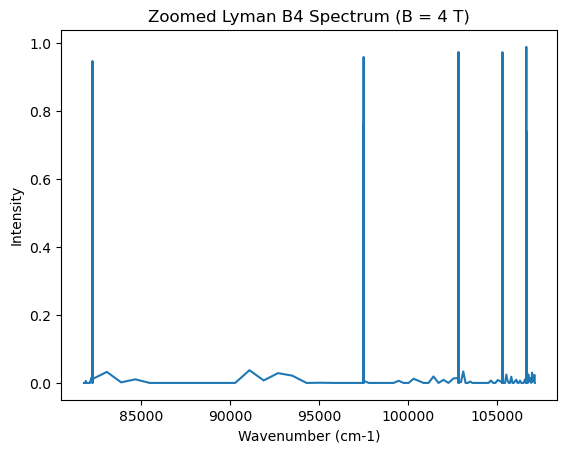

In [7]:
# peak region
peak_region = data[(data['wavenumber_cm-1'] > xmin) &(data['wavenumber_cm-1'] < xmax)]
x = peak_region['wavenumber_cm-1']
y = peak_region['intensity']
plt.plot(x, y)
plt.xlabel('Wavenumber (cm-1)')
plt.ylabel('Intensity')
plt.title('Zoomed Lyman B4 Spectrum (B = 4 T)')
plt.show()


## 1.B - The Bohr Model

Let's use the first successful model of the H atom spectrum - the Bohr model - and see what happens as we add a magnetic perturbation. 

<note> material explaining classical relation between angular momentum and magnetism goes here</note>

Classically, the potential energy of an object with a magnetic dipole in a magnetic field B is given by $ U = -\vec{\mu} \cdot \vec{B}$, which gives us the following expression for the energy of an electron in a magnetic field:
$$
V_m = \frac{e}{2m_e}\vec{L} \cdot \vec{B}
$$

The premise of the Bohr model is that the electron orbits the nucleus with a fixed angular momentum of absolute value $\hbar$, so we can plug this in to obtain

$$
V_m = \frac{\hbar{}e}{2m_e}Bcos(\theta)
$$
where theta is (etc) and B is the magnitude of the vector

Classically, a A magnetic field exerts a torque on a magnetic dipole that causes it to align with the field. So we can assume that at equilibrium cosine Theta equals 0. So our bore model. Magnetism edition might look like this. 

$$
V_m = \frac{\hbar{}e}{2m_e}B
$$

Incidentally, the quantity $\frac{\hbar{}e}{2m_e}$ is known as the Bohr Magneton. 

In [8]:
mu_B_cm_1 = 0.46686 # cm-1/T
R_H_cm_1 = 109679.25
print(R_H_cm_1)

#R_H_cm_1 = 109737
def bohr_energy_cm_1(n,B,alpha): # parameters at the end
    # make students optimize their own parameters.
    return  -alpha * R_H_cm_1/n**2 + mu_B_cm_1*n*B

109679.25


In [9]:
# generate spectrum by taking differences between energy levels
def bohr_transition_energies(B,alpha):
    E_1 = bohr_energy_cm_1(1,B,alpha) 
    transition_energies = []
    for n in range(2,6):
        E = bohr_energy_cm_1(n,B,alpha)
        E_trs = E - E_1
        transition_energies.append(E_trs)
    transition_energies = np.array(transition_energies)
    return transition_energies

In [10]:
def gaussian (x,mean,variance,amplitude):
    return amplitude * np.e**(-(x-mean)**2/(2 *variance))

def slater(x,mean,variance,amplitude):
    return amplitude * np.e**(-np.abs(x-mean)/variance)
 
def simulated_spectrum(transition_energies,xmin,xmax,npoints,amplitude=10):
    x = np.linspace(xmin,xmax,npoints)
    y = np.zeros_like(x)
    for energy in transition_energies:
        y += gaussian(x,energy,0.05,amplitude)
        #y += gaussian(x,energy,1,amplitude * 0.1)
        #y += gaussian(x,energy,0.1,amplitude * 0.5)
    return x,y

def display_spectrum(transition_energies,xmin,xmax,npoints,amplitude=10):
    x = np.linspace(xmin,xmax,npoints)
    y = np.zeros_like(x)
    for energy in transition_energies:
        y += gaussian(x,energy,0.0001,amplitude)
    return x,y

In [11]:
# normalized overlap
def overlap(y1,y2):
    """
    assumes y1 and y2 correspond to same x region
    """
    # need to prevent this from going to zero, add 1
    return np.dot(y1,y2) / (1 + np.linalg.norm(y1) * np.linalg.norm(y2))
    # shouldn't be possible for this to be bigger than 1...
   

In [12]:
def get_spectral_params(peak_region):
    region_min = peak_region['wavenumber_cm-1'].min()
    region_max = peak_region['wavenumber_cm-1'].max()
    npoints = len(peak_region)
    amp_max = peak_region['intensity'].max() / 2
    return region_min, region_max, npoints, amp_max

In [13]:
def spectra_overlap(transitions,peak_region):
    """_summary_
    Args:
        transitions (array-like): list of transition energies
        peak_region (pd.DataFrame): dataframe with spectral region to compare predictions to
    """
    region_min, region_max, npoints, amp_max = get_spectral_params(peak_region)
    spec_x,spec_y = simulated_spectrum(transitions,region_min,region_max,npoints,amp_max)
    return overlap(spec_y,peak_region['intensity'])

In [14]:
def compare_spectra(transitions,peak_region):
    region_min, region_max, npoints, amp_max = get_spectral_params(peak_region)
    sim_x,sim_y = simulated_spectrum(transitions,region_min,region_max,npoints,amp_max)
    exp_x,exp_y = peak_region['wavenumber_cm-1'],peak_region['intensity']
    plt.plot(sim_x,sim_y)
    plt.plot(exp_x,exp_y,alpha=0.5,linestyle='--')
    plt.show()

In [15]:
# need objective function for paramters
def overlap_noB(alpha,fit_data,B): # B is args
    e_trs = bohr_transition_energies(B,alpha)
    return - spectra_overlap(e_trs,fit_data) # must negate,

#### Optimization

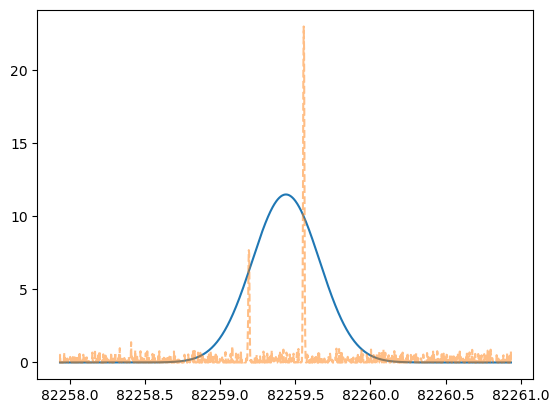

optimized alpha:
1.000001022569162


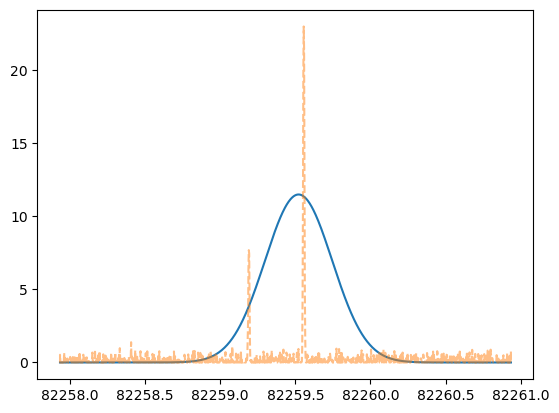

In [16]:
# numerically optimize
from scipy.optimize import minimize
# loading spectra

# load data
lyman_alpha_min = 82256
lyman_alpha_max = 82262
data = pd.read_csv("data/lyman_B0.csv")
filter = (data['wavenumber_cm-1'] < lyman_alpha_max) & (data['wavenumber_cm-1'] > lyman_alpha_min)
peak_region = data[filter]
#noise_filter = peak_region['intensity'] < peak_region['intensity'].max()/10
#peak_region.loc[noise_filter,'intensity'] = 0
fit_data = peak_region

# compare before
naive_trans = bohr_transition_energies(0,1)
compare_spectra(naive_trans,peak_region)

# optimize
B = 0
alpha_guess = 1.0
result_param = minimize(overlap_noB, alpha_guess, args=(fit_data,B), method='CG')    #YOUR COMMENT HERE
#print param
new_alpha = result_param.x[0]
print("optimized alpha:")
print(new_alpha)

# compare after
new_trans = bohr_transition_energies(0,new_alpha)
compare_spectra(new_trans,peak_region)

#### Genetic Algorithm

In [17]:
def load_spectrum(filename):
    data = pd.read_csv(f"data/{filename}")
    lyman_alpha_min = 82258.5
    lyman_alpha_max = 82260.5
    filter = (data['wavenumber_cm-1'] < lyman_alpha_max) & (data['wavenumber_cm-1'] > lyman_alpha_min)
    peak_region = data[filter]
    noise_filter = peak_region['intensity'] < peak_region['intensity'].max()/10
    peak_region.loc[noise_filter,'intensity'] = 0
    max_intens = peak_region['intensity'].max()
    print("max intensity:")
    print(max_intens)
    return peak_region

In [18]:
new_alpha = 1.0000121643256625 # from last part
def bohr_energy_w_mag(n,B,alpha):
    return - R_H_cm_1/n**2 - alpha * n* mu_B_cm_1 * B # TODO: CHECK SIGN

In [ ]:
def bohr_mag_trans_energies(B,alpha):
    E_1 = bohr_energy_w_mag(1,B,alpha)
    transitions = []
    n = 2
    E = bohr_energy_w_mag(n,B,alpha)
    E_trs = E - E_1
    transitions.append(E_trs)
    transitions = np.array(transitions)
    return transitions

In [20]:
def params_overlap(trs_function):
    # needs to allow for flexible number of params
    def calculate_overlap(params,fit_data,B):
        e_trs = trs_function(B,*params)
        return - spectra_overlap(e_trs,fit_data) # must negate to minimize
    return calculate_overlap 

In [21]:
def optimization_workflow(transition_function,B,fit_data):
    objective_function = params_overlap(transition_function)
    param_guess = 1
    naive_trans = transition_function(B,param_guess)
    compare_spectra(naive_trans,fit_data)
    # optimize
    result = minimize(objective_function, param_guess, args=(fit_data,B), method='CG')    #YOUR COMMENT HERE
    #print param
    new_param = result.x[0]
    print("optimized parameter:")
    print(new_param)

    new_trans = transition_function(B,new_param)
    compare_spectra(new_trans,fit_data)
    # output is the optimized parameter
    return new_param

In [22]:
from scipy.optimize import differential_evolution

def genetic_workflow(transition_function,bounds,B,fit_data):
    objective_function = params_overlap(transition_function)
    param_guess = [np.average(bound) for bound in bounds]
    naive_trans = transition_function(B,*param_guess)
    compare_spectra(naive_trans,fit_data)
    result = differential_evolution(
        objective_function,
        bounds = bounds,
        args =(fit_data,B),
        maxiter=1000,
        popsize=50,
        tol=1e-3,
        mutation=(0.5,1.5),
        seed=42
    )
    new_param = result.x
    print("optimized parameter:")
    print(new_param)
    
    new_trans = transition_function(B,*new_param)
    compare_spectra(new_trans,fit_data)
    print("transitions:")
    print(new_trans)
    return new_param

max intensity:
4.092645


/tmp/ipykernel_297378/1529924257.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  peak_region.loc[noise_filter,'intensity'] = 0


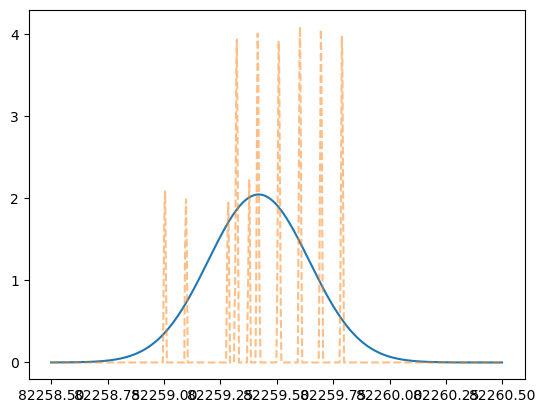

optimized parameter:
[0.5]


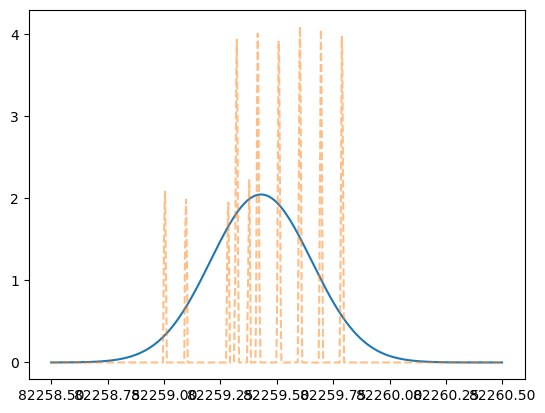

transitions:
[ 82259.4304971   97492.65266087 102824.2758663  105292.0519884 ]


array([0.5])

In [23]:
spec = load_spectrum("lyman_B03.csv")
B = 0.03
#optimization_workflow(bohr_mag_trans_energies,B,b03)
bounds = [
    (0.5,2.0),
]
genetic_workflow(bohr_mag_trans_energies,bounds,B,spec)

max intensity:
4.092645


/tmp/ipykernel_297378/1529924257.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  peak_region.loc[noise_filter,'intensity'] = 0


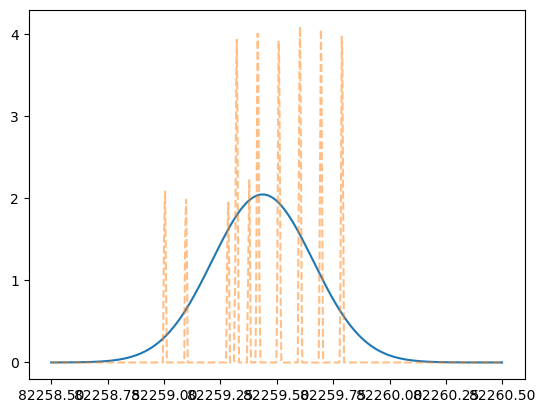

optimized parameter:
[1.60335706]


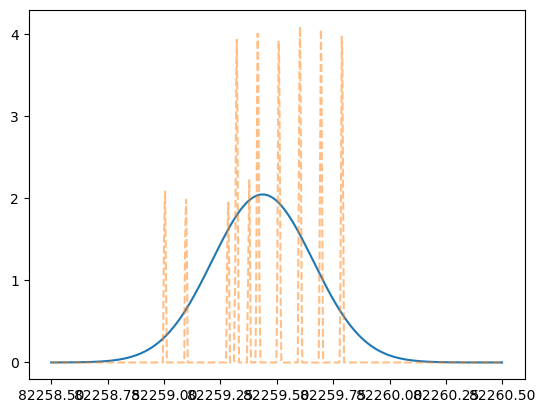

transitions:
[ 82259.4375      97492.66666667 102824.296875   105292.08      ]


array([1.60335706])

In [24]:
b03 = load_spectrum("lyman_B03.csv")
B = 0.00
#optimization_workflow(bohr_mag_trans_energies,B,b03)
bounds = [
    (0.5,2.0),
]
genetic_workflow(bohr_mag_trans_energies,bounds,B,b03)

max intensity:
0.944128


/tmp/ipykernel_297378/1529924257.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  peak_region.loc[noise_filter,'intensity'] = 0


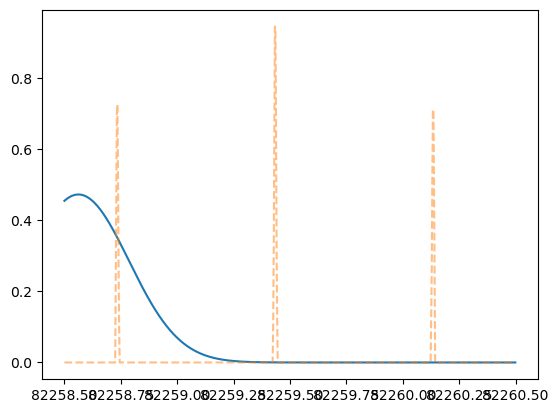

optimized parameter:
[1.03294016]


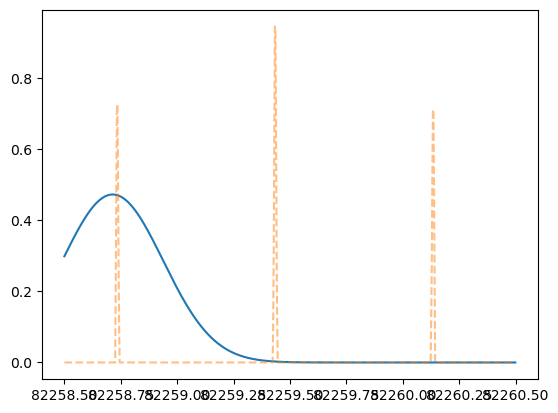

transitions:
[ 82258.71414233  97491.21995133 102822.126802   105289.18656933]


array([1.03294016])

In [25]:
data = load_spectrum("lyman_B15.csv")
B = 1.5
#optimization_workflow(bohr_mag_trans_energies,B,b4)
bounds = [
    (0.5,2),
]
genetic_workflow(bohr_mag_trans_energies,bounds,B,data)

## 1.C - The Orbital Model

The Hydrogen Atom model might agree a bit better.

In [26]:

def simulated_spectrum(transition_energies,xmin,xmax,npoints,amplitude=10):
    x = np.linspace(xmin,xmax,npoints)
    y = np.zeros_like(x)
    for energy in transition_energies:
        y += gaussian(x,energy,0.0001,amplitude)
        y += gaussian(x,energy,10,amplitude * 0.0001)
        y += gaussian(x,energy,1,amplitude * 0.001)
        
    return x,y

def display_spectrum(transition_energies,xmin,xmax,npoints,amplitude=10):
    x = np.linspace(xmin,xmax,npoints)
    y = np.zeros_like(x)
    for energy in transition_energies:
        y += gaussian(x,energy,0.0001,amplitude)
    return x,y

In [27]:
# students use H atom model here
new_alpha
# same gross structure as Bohr
def H_energy_level(n, l, m_l, B, alpha):
    # they write it?
    return - R_H_cm_1/n**2 + alpha* m_l*mu_B_cm_1*B # TODO: check sign


In [ ]:
# make transition energies by taking differences
def H_transitions(B,alpha):
    E_1 = H_energy_level(1,0,0,B,alpha)
    transitions = []
    n = 2    
    for l in range(0,n):
        for m_l in range(-l,l+1):
            E = H_energy_level(n,l,m_l,B,alpha)
            E_trs = E - E_1
            transitions.append(E_trs)
    transitions = np.array(transitions)
    return transitions

max intensity:
22.97661


/tmp/ipykernel_297378/1529924257.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  peak_region.loc[noise_filter,'intensity'] = 0


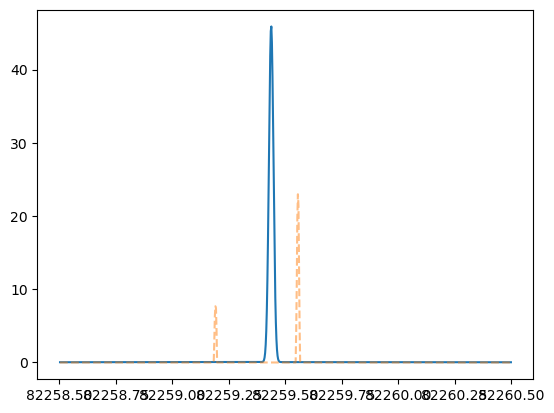

optimized parameter:
[1.60335706]


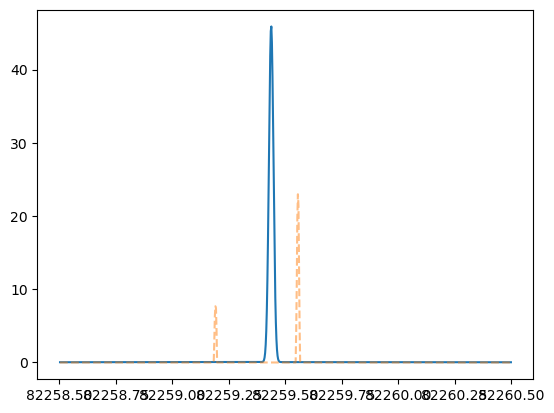

transitions:
[ 82259.4375      82259.4375      82259.4375      82259.4375
  97492.66666667  97492.66666667  97492.66666667  97492.66666667
  97492.66666667  97492.66666667  97492.66666667  97492.66666667
  97492.66666667 102824.296875   102824.296875   102824.296875
 102824.296875   102824.296875   102824.296875   102824.296875
 102824.296875   102824.296875   102824.296875   102824.296875
 102824.296875   102824.296875   102824.296875   102824.296875
 102824.296875   105292.08       105292.08       105292.08
 105292.08       105292.08       105292.08       105292.08
 105292.08       105292.08       105292.08       105292.08
 105292.08       105292.08       105292.08       105292.08
 105292.08       105292.08       105292.08       105292.08
 105292.08       105292.08       105292.08       105292.08
 105292.08       105292.08      ]


array([1.60335706])

In [29]:
# use provided function to compare to real spectra
spec = load_spectrum("lyman_B0.csv")
B = 0
bounds = [
    (0.5,2.0),
]
genetic_workflow(
    H_transitions,
    bounds,
    B,
    spec
    )

max intensity:
4.092645


/tmp/ipykernel_297378/1529924257.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  peak_region.loc[noise_filter,'intensity'] = 0


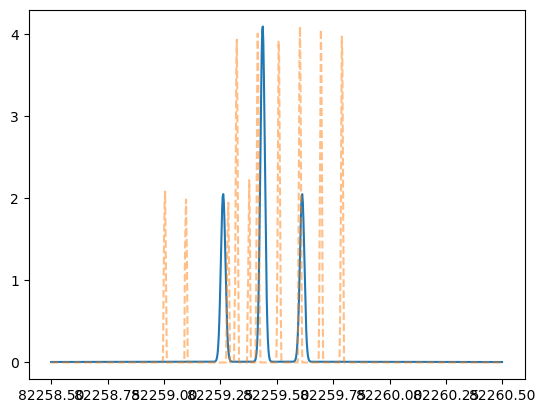

optimized parameter:
[1.15915155]


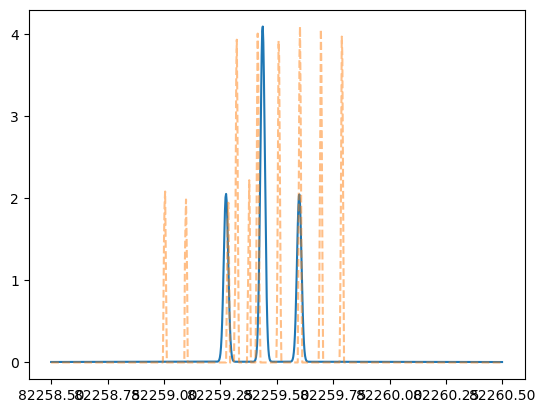

transitions:
[ 82259.4375      82259.27515155  82259.4375      82259.59984845
  97492.66666667  97492.50431822  97492.66666667  97492.82901511
  97492.34196977  97492.50431822  97492.66666667  97492.82901511
  97492.99136356 102824.296875   102824.13452655 102824.296875
 102824.45922345 102823.97217811 102824.13452655 102824.296875
 102824.45922345 102824.62157189 102823.80982966 102823.97217811
 102824.13452655 102824.296875   102824.45922345 102824.62157189
 102824.78392034 105292.08       105291.91765155 105292.08
 105292.24234845 105291.75530311 105291.91765155 105292.08
 105292.24234845 105292.40469689 105291.59295466 105291.75530311
 105291.91765155 105292.08       105292.24234845 105292.40469689
 105292.56704534 105291.43060621 105291.59295466 105291.75530311
 105291.91765155 105292.08       105292.24234845 105292.40469689
 105292.56704534 105292.72939379]


array([1.15915155])

In [30]:
# use provided function to compare to real spectra
spec = load_spectrum("lyman_B03.csv")
B = 0.3
bounds = [
    (0.5,2.0),
]
genetic_workflow(
    H_transitions,
    bounds,
    B,
    spec
    )

max intensity:
0.944128


/tmp/ipykernel_297378/1529924257.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  peak_region.loc[noise_filter,'intensity'] = 0


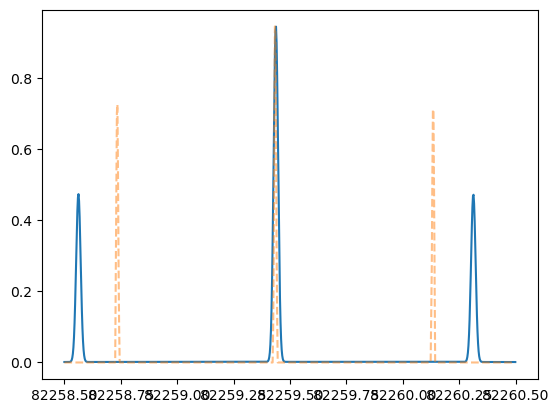

optimized parameter:
[0.99970211]


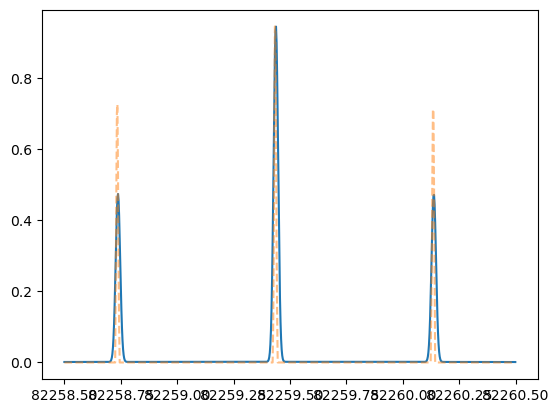

transitions:
[ 82259.4375      82258.73741861  82259.4375      82260.13758139
  97492.66666667  97491.96658528  97492.66666667  97493.36674806
  97491.26650389  97491.96658528  97492.66666667  97493.36674806
  97494.06682945 102824.296875   102823.59679361 102824.296875
 102824.99695639 102822.89671222 102823.59679361 102824.296875
 102824.99695639 102825.69703778 102822.19663083 102822.89671222
 102823.59679361 102824.296875   102824.99695639 102825.69703778
 102826.39711917 105292.08       105291.37991861 105292.08
 105292.78008139 105290.67983722 105291.37991861 105292.08
 105292.78008139 105293.48016278 105289.97975583 105290.67983722
 105291.37991861 105292.08       105292.78008139 105293.48016278
 105294.18024417 105289.27967444 105289.97975583 105290.67983722
 105291.37991861 105292.08       105292.78008139 105293.48016278
 105294.18024417 105294.88032556]


array([0.99970211])

In [31]:
# use provided function to compare to real spectra
spec = load_spectrum("lyman_B15.csv")
B = 1.5
bounds = [
    (0.5,2.0),
]
genetic_workflow(
    H_transitions,
    bounds,
    B,
    spec
    )


# Part 2 - Spin

## 2A - J

In [32]:
# students use H atom model here
# same gross structure as Bohr
def H_energy_spin(n, l, m_l, m_s,B, beta):
    # they write it?
    m_j = (m_l+m_s)
    return - R_H_cm_1/n**2 + beta * m_j*mu_B_cm_1*B # TODO: check sign


In [46]:
# make transition energies by taking differences
def H_transitions_spin(B,beta):
    E_1 = H_energy_spin(1,0,0,0,B,beta)
    transitions = []
    n = 2
    for l in range(0,n):
        for m_l in range(-l,l+1):
            for m_s in [-1/2,1/2]:
                E = H_energy_spin(n,l,m_l,m_s,B,beta)
                E_trs = E - E_1
                transitions.append(E_trs)
    transitions = np.array(transitions)
    return transitions

/tmp/ipykernel_297378/1529924257.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  peak_region.loc[noise_filter,'intensity'] = 0


max intensity:
22.97661


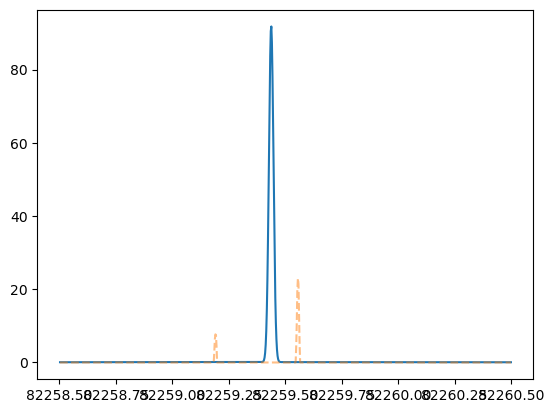

optimized parameter:
[1.60335706]


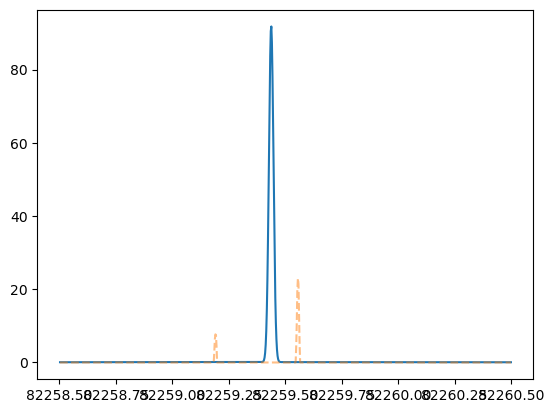

transitions:
[82259.4375 82259.4375 82259.4375 82259.4375 82259.4375 82259.4375
 82259.4375 82259.4375]


array([1.60335706])

In [47]:
spec = load_spectrum("lyman_B0.csv")
B = 0
bounds = [
    (0.5,2.0),
]
genetic_workflow(
    H_transitions_spin,
    bounds,
    B,
    spec
    )

max intensity:
4.092645


/tmp/ipykernel_297378/1529924257.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  peak_region.loc[noise_filter,'intensity'] = 0


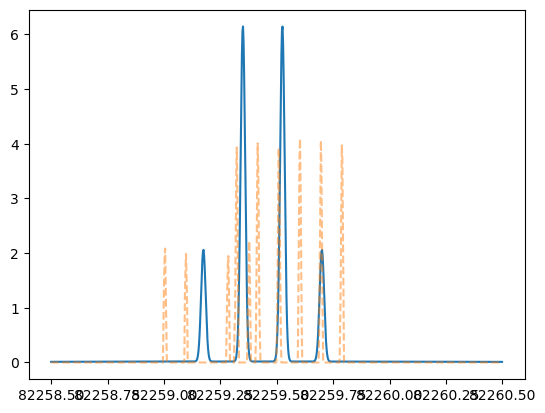

optimized parameter:
[1.65545245]


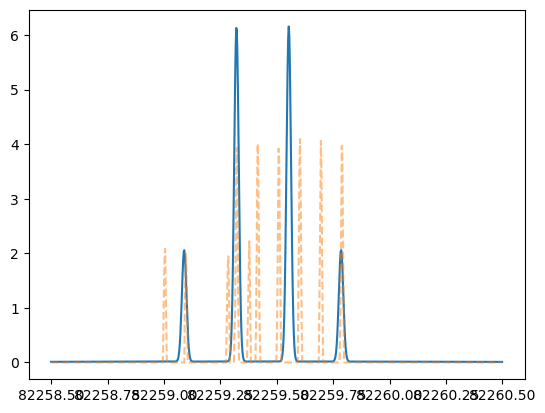

transitions:
[82259.32157032 82259.55342968 82259.08971096 82259.32157032
 82259.32157032 82259.55342968 82259.55342968 82259.78528904]


array([1.65545245])

In [48]:
spec = load_spectrum("lyman_B03.csv")
B = 0.3
bounds = [
    (0.5,2.0),
]
genetic_workflow(
    H_transitions_spin,
    bounds,
    B,
    spec
    )

max intensity:
0.944128


/tmp/ipykernel_297378/1529924257.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  peak_region.loc[noise_filter,'intensity'] = 0


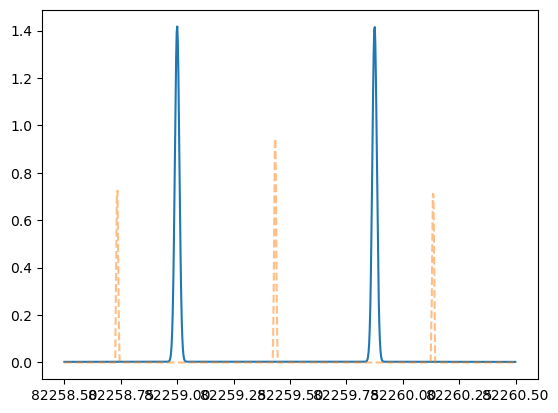

optimized parameter:
[1.99940342]


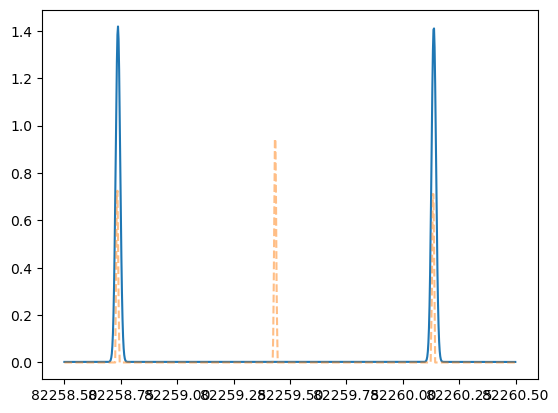

transitions:
[ 82258.73741889  82260.13758111  82257.33725667  82258.73741889
  82258.73741889  82260.13758111  82260.13758111  82261.53774333
  97491.96658556  97493.36674778  97490.56642334  97491.96658556
  97491.96658556  97493.36674778  97493.36674778  97494.76691
  97489.16626111  97490.56642334  97490.56642334  97491.96658556
  97491.96658556  97493.36674778  97493.36674778  97494.76691
  97494.76691     97496.16707222 102823.59679389 102824.99695611
 102822.19663167 102823.59679389 102823.59679389 102824.99695611
 102824.99695611 102826.39711833 102820.79646945 102822.19663167
 102822.19663167 102823.59679389 102823.59679389 102824.99695611
 102824.99695611 102826.39711833 102826.39711833 102827.79728055
 102819.39630723 102820.79646945 102820.79646945 102822.19663167
 102822.19663167 102823.59679389 102823.59679389 102824.99695611
 102824.99695611 102826.39711833 102826.39711833 102827.79728055
 102827.79728055 102829.19744277 105291.37991889 105292.78008111
 105289.97975667 1

array([1.99940342])

In [36]:
spec = load_spectrum("lyman_B15.csv")
B = 1.5

bounds = [
    (0.5,2.0),
]
genetic_workflow(
    H_transitions_spin,
    bounds,
    B,
    spec
    )

## 2.B Different betas for different angular momenta

When you can't make it fit, just add more parameters...

In [49]:
def H_transitions_spin_1(B,alpha_0,alpha_1):
    params = [alpha_0,alpha_1]
    E_1 = H_energy_spin(1,0,0,0,B,alpha_0)
    transitions = []
    n= 2
    for l in range(0,n):
        for m_l in range(-l,l+1):
            for m_s in [-1/2,1/2]:
                E = H_energy_spin(n,l,m_l,m_s,B,params[l])
                E_trs = E - E_1
                transitions.append(E_trs)
    transitions = np.array(transitions)
    return transitions

max intensity:
22.97661


/tmp/ipykernel_297378/1529924257.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  peak_region.loc[noise_filter,'intensity'] = 0


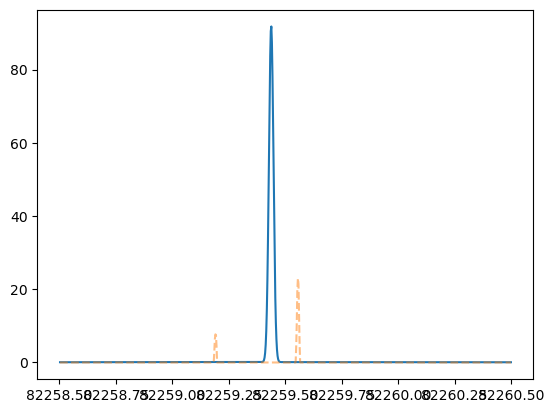

optimized parameter:
[1.95350627 0.67350865]


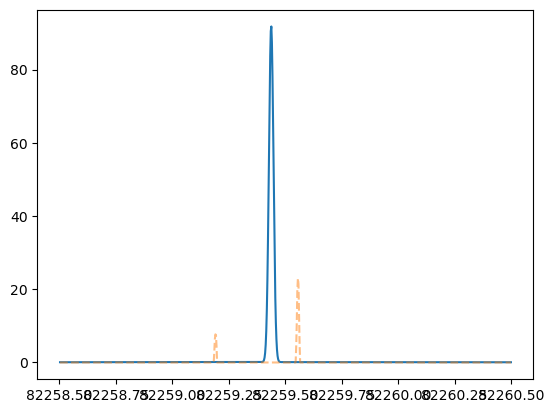

transitions:
[82259.4375 82259.4375 82259.4375 82259.4375 82259.4375 82259.4375
 82259.4375 82259.4375]


array([1.95350627, 0.67350865])

In [38]:
spec = load_spectrum("lyman_B0.csv")
B = 0
bounds = [
    (0.5,2.0),
    (0.5,2.0),
]
genetic_workflow(
    H_transitions_spin_1,
    bounds,
    B,
    spec
    )

max intensity:
4.092645


/tmp/ipykernel_297378/1529924257.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  peak_region.loc[noise_filter,'intensity'] = 0


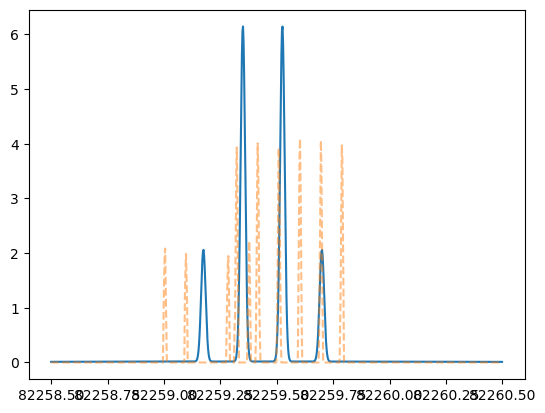

optimized parameter:
[0.97942944 1.65678104]


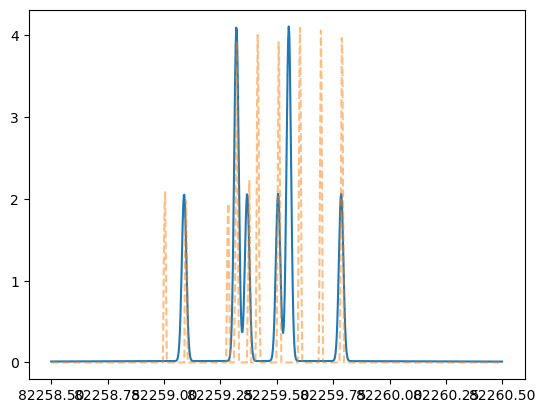

transitions:
[82259.36891154 82259.50608846 82259.08943184 82259.32147728
 82259.32147728 82259.55352272 82259.55352272 82259.78556816]


array([0.97942944, 1.65678104])

In [39]:
spec = load_spectrum("lyman_B03.csv")
B = 0.3
bounds = [
    (0.5,2.0),
    (0.5,2.0),
]
genetic_workflow(
    H_transitions_spin_1,
    bounds,
    B,
    spec
    )

max intensity:
0.944128


/tmp/ipykernel_297378/1529924257.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  peak_region.loc[noise_filter,'intensity'] = 0


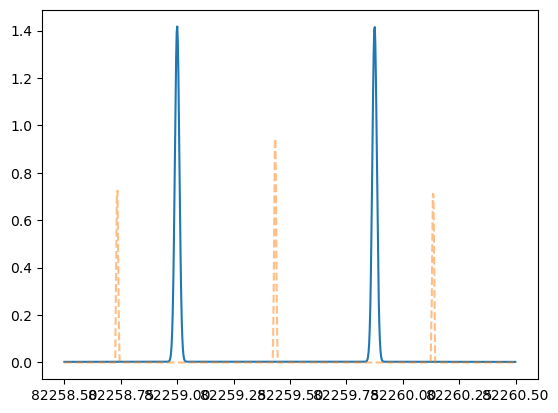

optimized parameter:
[1.99940115 1.99940402]


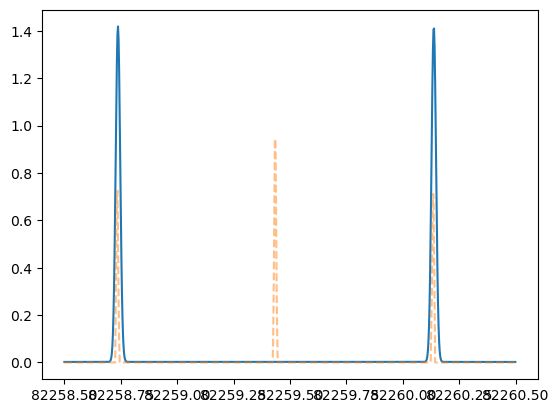

transitions:
[82258.73741968 82260.13758032 82257.33725603 82258.73741868
 82258.73741868 82260.13758132 82260.13758132 82261.53774397]


array([1.99940115, 1.99940402])

In [40]:
spec = load_spectrum("lyman_B15.csv")
B = 1.5
bounds = [
    (0.5,2.0),
    (0.5,2.0),
]
genetic_workflow(
    H_transitions_spin_1,
    bounds,
    B,
    spec
    )

## 2.B Spin-Orbit Coupling

In [104]:
def H_energy_soc(n, l, j,m_j,B, alpha):
    if l == 0:
        spin_orbit = 0
    else:
        spin_orbit = (1/137)**2 * R_H_cm_1 /(2 * n**3) * (j*(j+1) - l*(l+1) - 3/4)/(l*(l+1/2)*(l+1))
    return - R_H_cm_1/n**2 - alpha * m_j*mu_B_cm_1*B + spin_orbit # TODO: check sign


In [105]:
# this part will be provided as scaffolding, though students will be expected to leave comments
def H_transitions_soc(B,alpha_0,alpha_1,alpha_2):
    params = [alpha_1,alpha_2]
    E_1s = []
    for m_j in [-1/2,1/2]:
        E_1 = H_energy_soc(1,0,0.5,m_j,B,alpha_0)
        E_1s.append(E_1)
    transitions = []
    n = 2
    l = 1 # cause of selection rules
    for j in [l-1/2,l+1/2]:
        if j < 0:
            continue
        jndex = int(j-1/2)
        alpha = params[jndex]
        
        for m_j in np.arange(-j,j+1,1):
            E = H_energy_soc(n,l,j,m_j,B,alpha)
            for E_1 in E_1s:
                E_trs = E - E_1
                transitions.append(E_trs)
    transitions = np.array(transitions)
    return transitions

In [106]:
def gaussian (x,mean,stdev,amplitude):
    return amplitude * np.e**(-(x-mean)**2/(2 *stdev**2))

def simulated_spectrum(transition_energies,xmin,xmax,npoints,amplitude=10):
    x = np.linspace(xmin,xmax,npoints)
    y = np.zeros_like(x)
    for energy in transition_energies:
        y += gaussian(x,energy,0.01,amplitude)
        #y += gaussian(x,energy,1,amplitude * 0.1)
        # y += gaussian(x,energy,0.1,amplitude * 0.01)
    return x,y

def display_spectrum(transition_energies,xmin,xmax,npoints,amplitude=10):
    x = np.linspace(xmin,xmax,npoints)
    y = np.zeros_like(x)
    for energy in transition_energies:
        y += gaussian(x,energy,0.0001,amplitude)
    return x,y

max intensity:
22.97661


/tmp/ipykernel_297378/1529924257.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  peak_region.loc[noise_filter,'intensity'] = 0


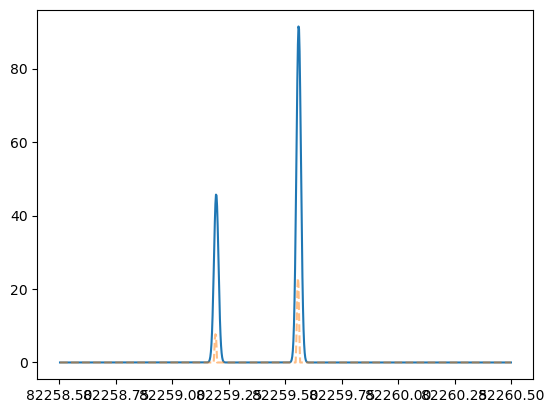

optimized parameter:
[1.80387718 1.78192428 1.39479922]


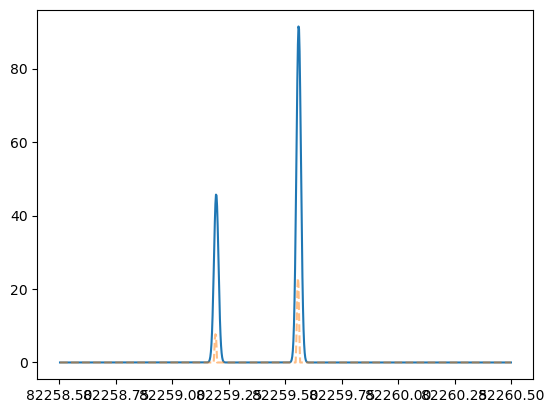

transitions:
[82259.19401506 82259.19401506 82259.19401506 82259.19401506
 82259.55924247 82259.55924247 82259.55924247 82259.55924247
 82259.55924247 82259.55924247 82259.55924247 82259.55924247]


array([1.80387718, 1.78192428, 1.39479922])

In [107]:
spec = load_spectrum("lyman_B0.csv")
B = 0
bounds = [
    (0.3,2.0),
    (0.3,2.0),
    (0.3,2.0),
]
genetic_workflow(
    H_transitions_soc,
    bounds,
    B,
    spec
    )

/tmp/ipykernel_297378/1529924257.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  peak_region.loc[noise_filter,'intensity'] = 0


max intensity:
4.092645


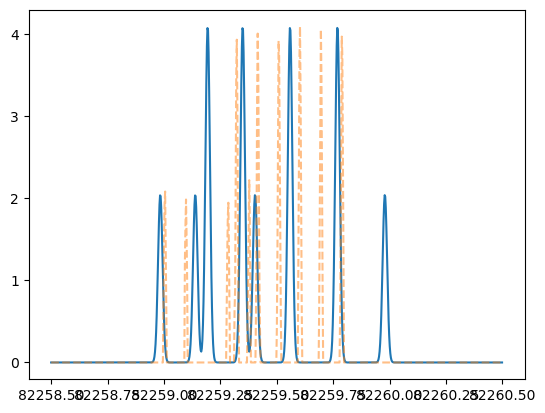

optimized parameter:
[1.99735526 0.66449107 1.33062466]


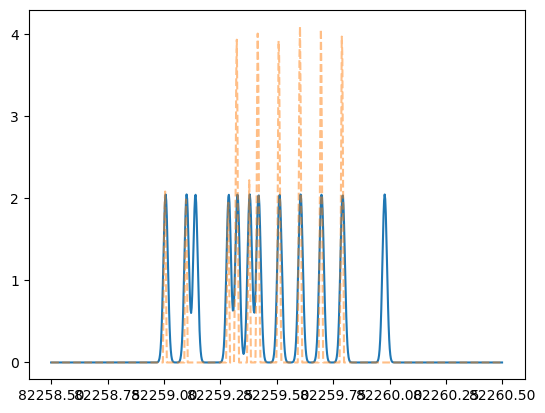

transitions:
[82259.10067592 82259.3804215  82259.00760863 82259.28735421
 82259.69891662 82259.9786622  82259.51255199 82259.79229757
 82259.32618736 82259.60593294 82259.13982273 82259.41956832]


array([1.99735526, 0.66449107, 1.33062466])

In [110]:
spec = load_spectrum("lyman_B03.csv")
B = 0.3
bounds = [
    (0.5,2.5),
    (0.5,2.5),
    (0.5,2.5),
]
genetic_workflow(
    H_transitions_soc,
    bounds,
    B,
    spec
    )

max intensity:
0.944128


/tmp/ipykernel_297378/1529924257.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  peak_region.loc[noise_filter,'intensity'] = 0


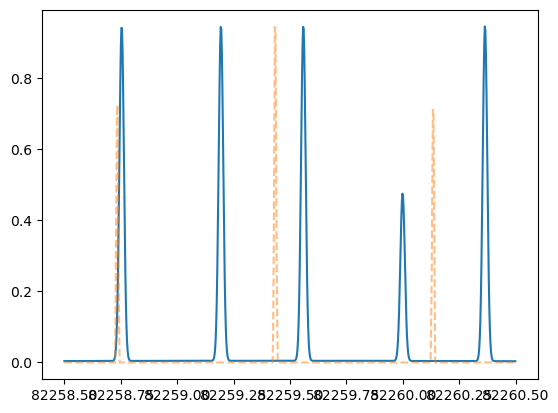

optimized parameter:
[0.99996858 1.09514067 0.99968076 0.51060645 1.99753744]


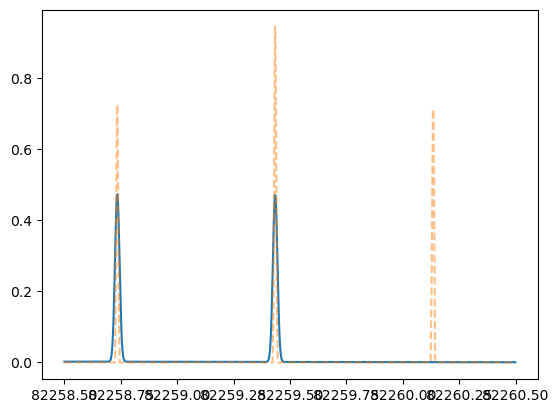

transitions:
[82256.41490907 82257.1149755  82256.05733648 82256.75740291
 82258.73438139 82259.43444783 82257.3355259  82258.03559234
 82255.93667041 82256.63673685 82254.53781492 82255.23788135]


array([0.99996858, 1.09514067, 0.99968076, 0.51060645, 1.99753744])

In [77]:
spec = load_spectrum("lyman_B15.csv")
B = 1.5
bounds = [
    (0.999,1.001),
    (0.9,1.1),
    (0.3,2.0),
    (0.3,2.0),
    (0.3,2.0),
]
genetic_workflow(
    H_transitions_soc,
    bounds,
    B,
    spec
    )

In [111]:
from scipy.optimize import dual_annealing
def annealing_workflow(transition_function, bounds, B, fit_data):
    objective_function = params_overlap(transition_function)
    
    # show initial guess (midpoint of bounds)
    param_guess = [np.average(bound) for bound in bounds]
    naive_trans = transition_function(B, *param_guess)
    compare_spectra(naive_trans, fit_data)
    
    result = dual_annealing(
        objective_function,
        bounds=bounds,
        args=(fit_data, B),
        maxiter=5000,
        seed=42,
    )
    
    new_params = result.x
    print("optimized parameters:")
    print(new_params)
    print("objective value:", result.fun)
    
    new_trans = transition_function(B, *new_params)
    compare_spectra(new_trans, fit_data)
    return new_params

max intensity:
4.092645


/tmp/ipykernel_297378/1529924257.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  peak_region.loc[noise_filter,'intensity'] = 0


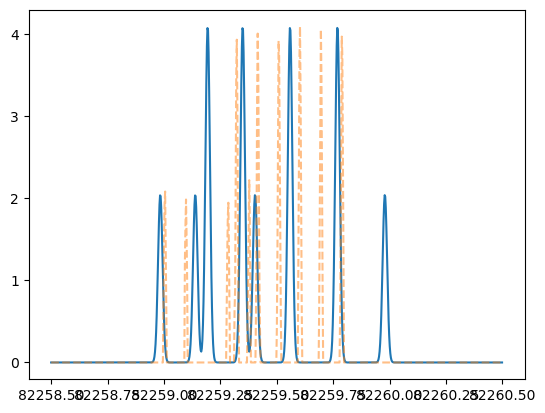

optimized parameters:
[0.66553368 1.99758434 1.33172894]
objective value: -0.6876807345051132


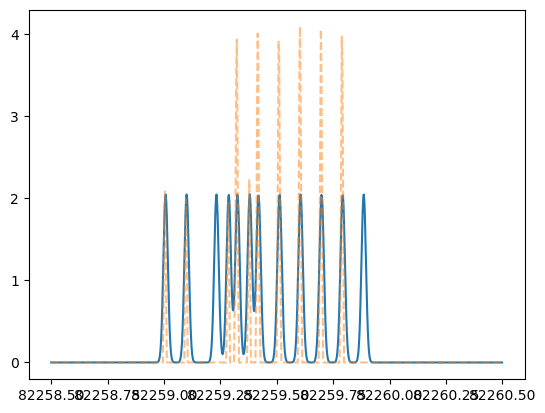

array([0.66553368, 1.99758434, 1.33172894])

In [112]:
spec = load_spectrum("lyman_B03.csv")
B = 0.3
bounds = [
    (0.5,2.5),
    (0.5,2.5),
    (0.5,2.5),
]
annealing_workflow(
    H_transitions_soc,
    bounds,
    B,
    spec
    )